In [35]:
import numpy as np
import pandas as pd

In [36]:
am92 = pd.read_csv("am92.csv").set_index("age")
print(am92.head())
print(am92.dtypes)

           l0        l1        lU
age                              
30   0.000476  0.000558  0.000590
31   0.000490  0.000569  0.000602
32   0.000507  0.000584  0.000617
33   0.000527  0.000602  0.000636
34   0.000550  0.000624  0.000660
l0    float64
l1    float64
lU    float64
dtype: object


In [37]:
am92 = pd.read_csv("am92.csv")
am92.columns = ["age", "q0", "q1", "qu"]
am92 = am92.set_index("age")
am92.head()

,q0,q1,qu
age,,,
30,0.000476,0.000558,0.000590
31,0.000490,0.000569,0.000602
32,0.000507,0.000584,0.000617
33,0.000527,0.000602,0.000636
34,0.000550,0.000624,0.000660


In [38]:
def qx_select(entry_age, term, table=am92):
    """Death probability for each policy year from the AM92 select and ultimate rates."""
    qs = []
    for k in range(1, term + 1):          # policy year
        x = entry_age + k - 1             # age at start of that year
        if k == 1:
            q = table.loc[x, "q0"]        # duration 0 (select)
        elif k == 2:
            q = table.loc[x, "q1"]        # duration 1 (select)
        else:
            q = table.loc[x, "qu"]        # duration 2+ (ultimate)
        qs.append(q)
    return np.array(qs)

print(qx_select(30, 20).round(5))

[0.00048 0.00057 0.00062 0.00064 0.00066 0.00069 0.00072 0.00076 0.00081
 0.00087 0.00094 0.00101 0.0011  0.00121 0.00133 0.00146 0.00162 0.0018
 0.00201 0.00224]


In [39]:
def profit_test(age=30, term=20, sum_assured=1_000_000, premium=2_500,
                interest=0.07, risk_disc=0.10, mort_mult=1.0, lapse_mult=1.0):
    years = np.arange(1, term + 1)
    ages = age + years - 1

    # Assumptions
    qx = np.minimum(qx_select(age, term) * mort_mult, 1)           # AM92 x multiplier
    lapse = np.where(years == 1, 0.15, np.where(years == 2, 0.10, 0.05)) * lapse_mult
    expenses = np.where(years == 1, 0.50 * premium + 500, 0.10 * premium + 100)

    # Probability the policy is still in force at the start of each year
    in_force = np.ones(term)
    for t in range(1, term):
        in_force[t] = in_force[t - 1] * (1 - qx[t - 1]) * (1 - lapse[t - 1])

    # Profit per policy in force at start of year (reserves assumed zero)
    profit = (premium - expenses) * (1 + interest) - qx * sum_assured
    signature = profit * in_force

    npv = (signature / (1 + risk_disc) ** years).sum()
    pv_prem = (premium * in_force / (1 + risk_disc) ** (years - 1)).sum()

    table = pd.DataFrame({"Year": years, "Age": ages, "qx": qx.round(5),
                          "Lapse": lapse, "InForce": in_force.round(4),
                          "Profit": profit.round(0), "Signature": signature.round(0)})
    return npv, npv / pv_prem, table

In [40]:
npv, margin, table = profit_test()
print(f"NPV: {npv:,.0f}   Profit margin: {margin:.1%}")
table

NPV: 7,154   Profit margin: 47.2%


,Year,Age,qx,Lapse,InForce,Profit,Signature
0,1,30,0.00048,0.15,1.0000,326.0,326.0
1,2,31,0.00057,0.10,0.8496,1732.0,1471.0
2,3,32,0.00062,0.05,0.7642,1684.0,1287.0
3,4,33,0.00064,0.05,0.7255,1664.0,1208.0
4,5,34,0.00066,0.05,0.6888,1640.0,1130.0
5,6,35,0.00069,0.05,0.6540,1612.0,1054.0
6,7,36,0.00072,0.05,0.6208,1576.0,979.0
7,8,37,0.00076,0.05,0.5894,1536.0,905.0
8,9,38,0.00081,0.05,0.5595,1488.0,832.0
9,10,39,0.00087,0.05,0.5311,1430.0,760.0


,Scenario,NPV,Margin %
0,Base,7154,47.25
1,AM92 at 120%,6320,41.77
2,AM92 at 80%,7990,52.73
3,Lapses +50%,5794,46.72
4,Lapses -50%,8839,47.32
5,Interest 5%,6943,45.85
6,Risk discount 12%,6450,46.47


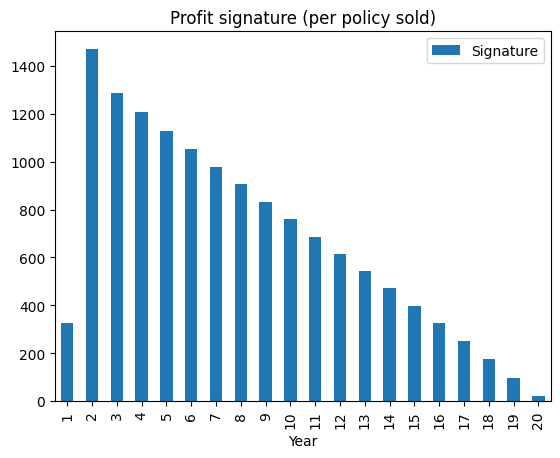

In [41]:
table.plot(x="Year", y="Signature", kind="bar", title="Profit signature (per policy sold)")

scenarios = {"Base": {},
             "AM92 at 120%": {"mort_mult": 1.2},
             "AM92 at 80%": {"mort_mult": 0.8},
             "Lapses +50%": {"lapse_mult": 1.5},
             "Lapses -50%": {"lapse_mult": 0.5},
             "Interest 5%": {"interest": 0.05},
             "Risk discount 12%": {"risk_disc": 0.12}}
rows = []
for name, changes in scenarios.items():
    n, m, _ = profit_test(**changes)
    rows.append({"Scenario": name, "NPV": round(n), "Margin %": round(m * 100, 2)})
pd.DataFrame(rows)